# Ali Abdullah Ahmad
# CWID - 20031246
# CS513-A

## Problem # 3 – Clustering (30 points)
Load the “hepatitis_B2.csv” dataset, from the Raw_data module in CANVAS,
into Python. This is a variation of the hepatitis dataset used for predicting
“Patient mortality”. Delete any row with missing value(s) and use Hierarchical and K-means
clustering Algorithms to cluster the records into two clusters based on AGE, SEX, ASCITES,
BILIRUBIN, ALK_PHOSPHATE, SGOT, ALBUMIN attributes only. Show the “Patient mortality”
versus clusters.
(Distance = Euclidian , linkage=ward)

In [2]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster

In [3]:
# Load the dataset
file_path = 'D:/Stevens GIT/Stevens_IT-MS_in_CS/SPRING_25/CS513_Knowledge_Discovery&Data_Mining/Final/hepatitis_B2.csv'  # Adjust path if needed
df = pd.read_csv(file_path)
df.head()

,Class,AGE,SEX,STEROID,ANTIVIRALS,FATIGUE,MALAISE,ANOREXIA,LIVER_BIG,LIVER_FIRM,SPLEEN_PALPABLE,SPIDERS,ASCITES,VARICES,BILIRUBIN,ALK_PHOSPHATE,SGOT,ALBUMIN,HISTOLOGY,Age_Quartile
0,1,39,1,1,1,1,1,2,2,1,2,2,2,2,2.3,280,98,3.8,1,Q2
1,1,37,1,2,2,1,2,2,2,2,2,1,2,2,0.6,67,28,4.2,1,Q2
2,1,58,1,2,2,1,2,2,1,1,1,1,2,2,2.0,167,242,3.3,1,Q4
3,1,30,1,2,2,1,1,1,2,1,2,1,1,1,2.5,165,64,2.8,2,Q1
4,1,38,1,1,2,1,1,1,2,1,2,1,1,1,1.2,118,16,2.8,2,Q2


Columns: Index(['Class', 'AGE', 'SEX', 'STEROID', 'ANTIVIRALS', 'FATIGUE', 'MALAISE',
       'ANOREXIA', 'LIVER_BIG', 'LIVER_FIRM', 'SPLEEN_PALPABLE', 'SPIDERS',
       'ASCITES', ' VARICES', 'BILIRUBIN', 'ALK_PHOSPHATE', 'SGOT', 'ALBUMIN',
       'HISTOLOGY', 'Age_Quartile'],
      dtype='object')


c:\Users\abdul\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


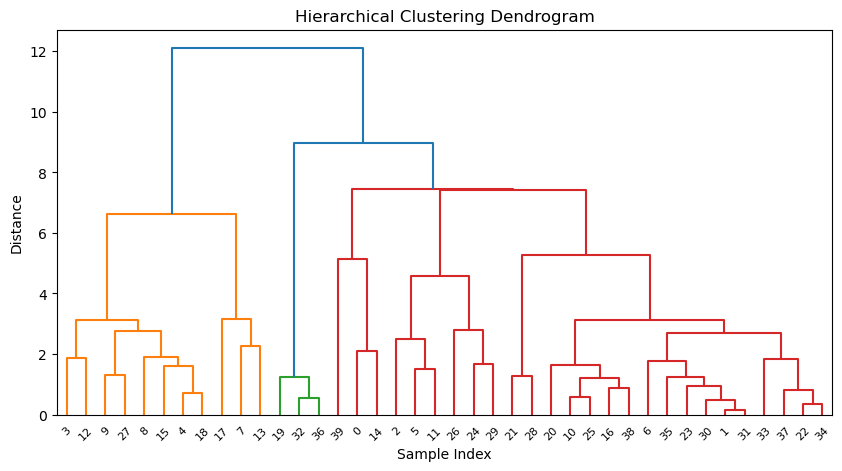

KMeans Clustering vs Mortality:
 KMeans_Cluster   0   1
Class                 
1               12   7
2                2  19

Hierarchical Clustering vs Mortality:
 Hierarchical_Cluster   0   1
Class                       
1                     10   9
2                      1  20


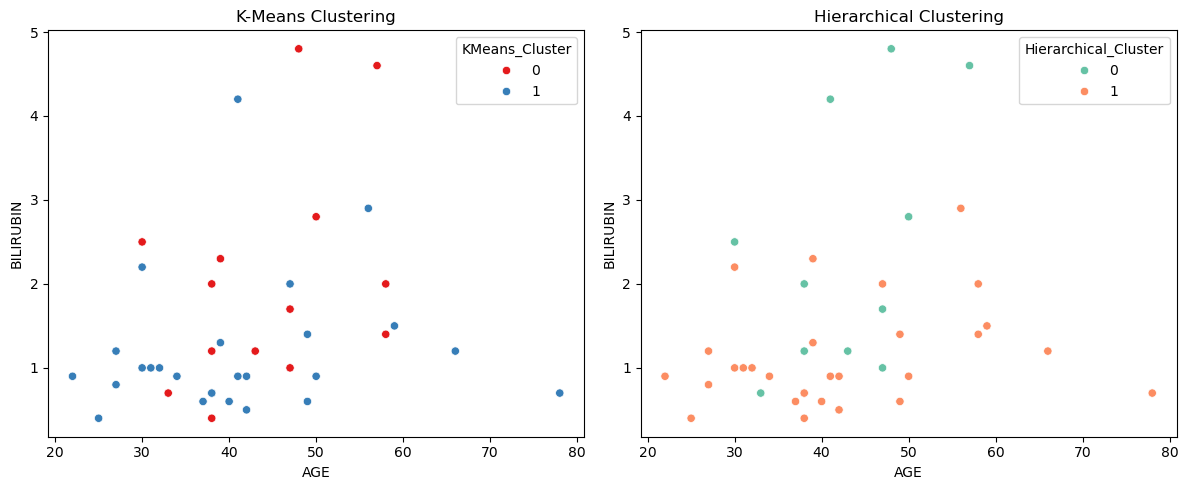

In [4]:
# Show column names to confirm structure (optional)
print("Columns:", df.columns)

# Drop rows with any missing values
df_clean = df.dropna()

# Select relevant features for clustering
features = ['AGE', 'SEX', 'ASCITES', 'BILIRUBIN', 'ALK_PHOSPHATE', 'SGOT', 'ALBUMIN']
X = df_clean[features]

# Standardize the data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# K-Means Clustering
kmeans = KMeans(n_clusters=2, random_state=42)
df_clean['KMeans_Cluster'] = kmeans.fit_predict(X_scaled)


# Hierarchical Clustering
linkage_matrix = linkage(X_scaled, method='ward', metric='euclidean')
df_clean['Hierarchical_Cluster'] = fcluster(linkage_matrix, t=2, criterion='maxclust') - 1  # To make clusters 0/1

# Plot Dendrogram
plt.figure(figsize=(10, 5))
dendrogram(linkage_matrix)
plt.title('Hierarchical Clustering Dendrogram')
plt.xlabel('Sample Index')
plt.ylabel('Distance')
plt.show()

# Clusters with Patient Mortality
mortality_col = 'Class'  

print("KMeans Clustering vs Mortality:\n", pd.crosstab(df_clean[mortality_col], df_clean['KMeans_Cluster']))
print("\nHierarchical Clustering vs Mortality:\n", pd.crosstab(df_clean[mortality_col], df_clean['Hierarchical_Cluster']))


#Plot Clusters (AGE vs BILIRUBIN)
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.scatterplot(data=df_clean, x='AGE', y='BILIRUBIN', hue='KMeans_Cluster', palette='Set1')
plt.title('K-Means Clustering')

plt.subplot(1, 2, 2)
sns.scatterplot(data=df_clean, x='AGE', y='BILIRUBIN', hue='Hierarchical_Cluster', palette='Set2')
plt.title('Hierarchical Clustering')

plt.tight_layout()
plt.show()